# Linear Motion Deblurring

This notebook is developed based on: 
> Hansen, P. C., Nagy, J. G., & O'Leary, D. P. (2006). Deblurring images: Matrices, spectra, and filtering. SIAM, Society for Industrial and Applied Mathematics. https://doi.org/10.1137/1.9780898718874

In [1]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

### Convert An Image File Into Normalized NumPy Array using Pillow

In [2]:
##############################################################################
# Note: .convert('L') is to make sure the image mode is in grayscale 
#       as common photo editors tend to use RGB even for black & white images.
##############################################################################

def convert_img_to_norm_np_arr(input_location, output_name, grayscale=False, save_converted_img=True):
    """Convert given image to normalized pixel values from [0,255] to [0,1] in Numpy array."""
    
    output_location = './motion_deblur_img/output/'
    os.makedirs(output_location, exist_ok=True)
    img = Image.open(input_location).convert('L') if grayscale else Image.open(input_location)
    
    if save_converted_img:
        img.save(os. path.join(output_location, output_name))
        
    return np.array(img).astype(np.float64) / 255

### Build Point Spread Function (PSF) for motion blur
> Hansen et al.(2006), Chapter 3.3 - Obtaining the PSF (p.25)

In [3]:
def build_horizontal_motion_psf(length, img_shape):
    """Build horizontal motion psf with padding zeros."""
    psf = np.zeros(img_shape)
    psf[0, :length] = 1 / length
    return psf

### Compute a blurred image from the original image
> Hansen et al.(2006), Chapter 4.2.2 - Computations with BCCB Matrices (p.44)

In [4]:
def compute_blurred_img(psf, orig_img):
    return np.real(np.fft.ifft2(np.fft.fft2(psf) * np.fft.fft2(orig_img)))

### Visualization

In [5]:
def plot_diff3(img1_arr, img1_label, img2_arr, img2_label, img3_arr, img3_label):
    _, sub = plt.subplots(1, 3, figsize=(12, 3.5))
    [s.axis('off') for s in sub]

    sub[0].imshow(img1_arr, cmap='gray')
    sub[0].set_title(img1_label, y = -0.1)
    sub[1].imshow(img2_arr, cmap='gray')
    sub[1].set_title(img2_label, y = -0.1)
    sub[2].imshow(img3_arr, cmap='gray')
    sub[2].set_title(img3_label, y = -0.1)
    
    plt.subplots_adjust(wspace=-0.2)
    plt.show()

----------
## Example 1 - Horizontal Motion Blur with a Grayscale Image

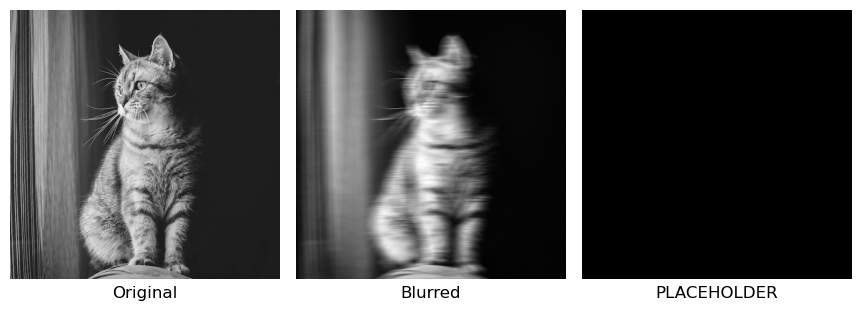

In [6]:
# Example 1 - Image Credit: Image by Arturo Anez from Pixabay

ex1_gray_arr = convert_img_to_norm_np_arr('./motion_deblur_img/input/Image_by_Arturo_Anez_from_Pixabay.jpg',
                                          'ex1_grayscale.jpg',
                                          grayscale=True)
ex1_psf = build_horizontal_motion_psf(25, ex1_gray_arr.shape)
ex1_blurred = compute_blurred_img(ex1_psf, ex1_gray_arr)

plot_diff3(ex1_gray_arr, 'Original', ex1_blurred, 'Blurred', np.zeros(ex1_gray_arr.shape), 'PLACEHOLDER')